# 09. Clustering Techniques

**Aim:** Apply K-Means and hierarchical clustering on image features and interpret results.

## Theory

Clustering is an unsupervised learning approach used to group similar samples without using labels during training. K-Means is centroid-based, hierarchical clustering builds nested groups through linkage, the elbow method helps choose a suitable number of clusters, and silhouette score measures how well-separated the resulting clusters are.

In [1]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score,
)

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings('ignore')
os.environ.setdefault('MPLCONFIGDIR', os.path.abspath('../logs/.mplconfig'))
os.makedirs(os.environ['MPLCONFIGDIR'], exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

TRAIN_DIR = Path('../data/PlantDoc-Dataset-master/train/')
TEST_DIR = Path('../data/PlantDoc-Dataset-master/test/')
MANIFEST_PATH = Path('../data/dataset_manifest.csv')
CLEAN_MANIFEST_PATH = Path('../data/dataset_manifest_clean.csv')
FEATURES_PATH = Path('../data/image_features.csv')

def scan_split(split_dir: Path, split_name: str) -> pd.DataFrame:
    records = []
    if not split_dir.exists():
        return pd.DataFrame(columns=['image_path', 'class_name', 'split'])
    for class_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()]):
        for image_path in sorted(class_dir.rglob('*')):
            if image_path.is_file():
                records.append({
                    'image_path': str(image_path.as_posix()),
                    'class_name': class_dir.name,
                    'split': split_name,
                })
    return pd.DataFrame(records)


def ensure_manifest(prefer_clean: bool = True) -> pd.DataFrame:
    target = CLEAN_MANIFEST_PATH if prefer_clean and CLEAN_MANIFEST_PATH.exists() else MANIFEST_PATH
    if target.exists():
        return pd.read_csv(target)

    train_df = scan_split(TRAIN_DIR, 'train')
    test_df = scan_split(TEST_DIR, 'test')
    full_df = pd.concat([train_df, test_df], ignore_index=True)
    full_df['class_name'] = full_df['class_name'].astype(str).str.strip()
    full_df = full_df.drop_duplicates(subset=['image_path']).reset_index(drop=True)
    return full_df


def validate_image(image_path: str):
    path = Path(image_path)
    if not path.exists():
        return False, 'missing'
    try:
        with Image.open(path) as img:
            img.verify()
        return True, 'ok'
    except Exception:
        return False, 'corrupt'


def load_rgb_image(image_path: str, size=(224, 224)):
    with Image.open(image_path) as img:
        rgb = img.convert('RGB').resize(size)
        return np.array(rgb)


def extract_rgb_features(image_array: np.ndarray) -> dict:
    channels = image_array.reshape(-1, 3)
    return {
        'mean_r': float(channels[:, 0].mean()),
        'mean_g': float(channels[:, 1].mean()),
        'mean_b': float(channels[:, 2].mean()),
        'std_r': float(channels[:, 0].std()),
        'std_g': float(channels[:, 1].std()),
        'std_b': float(channels[:, 2].std()),
    }


def ensure_features() -> pd.DataFrame:
    if FEATURES_PATH.exists():
        return pd.read_csv(FEATURES_PATH)

    manifest_df = ensure_manifest(prefer_clean=True).copy()
    quality_records = []
    for image_path in manifest_df['image_path']:
        valid, status = validate_image(image_path)
        quality_records.append((valid, status))
    manifest_df[['is_valid_image', 'file_status']] = pd.DataFrame(quality_records, index=manifest_df.index)
    manifest_df = manifest_df[manifest_df['is_valid_image']].copy().reset_index(drop=True)

    feature_rows = []
    for row in manifest_df.itertuples(index=False):
        image_array = load_rgb_image(row.image_path)
        feature_rows.append({
            'image_path': row.image_path,
            'class_name': row.class_name,
            'split': row.split,
            **extract_rgb_features(image_array),
        })

    features_df = pd.DataFrame(feature_rows)
    return features_df

from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

## Code

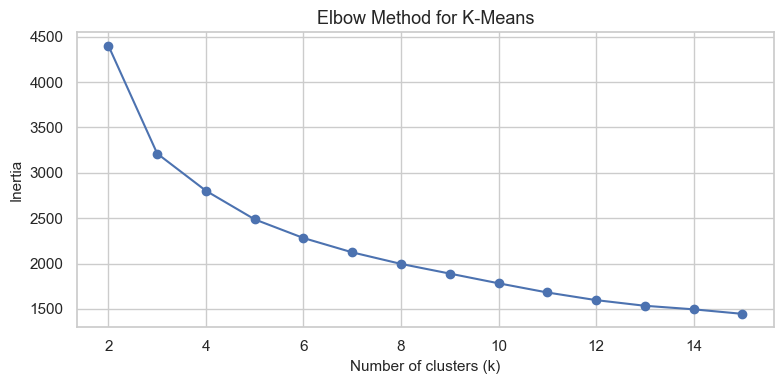

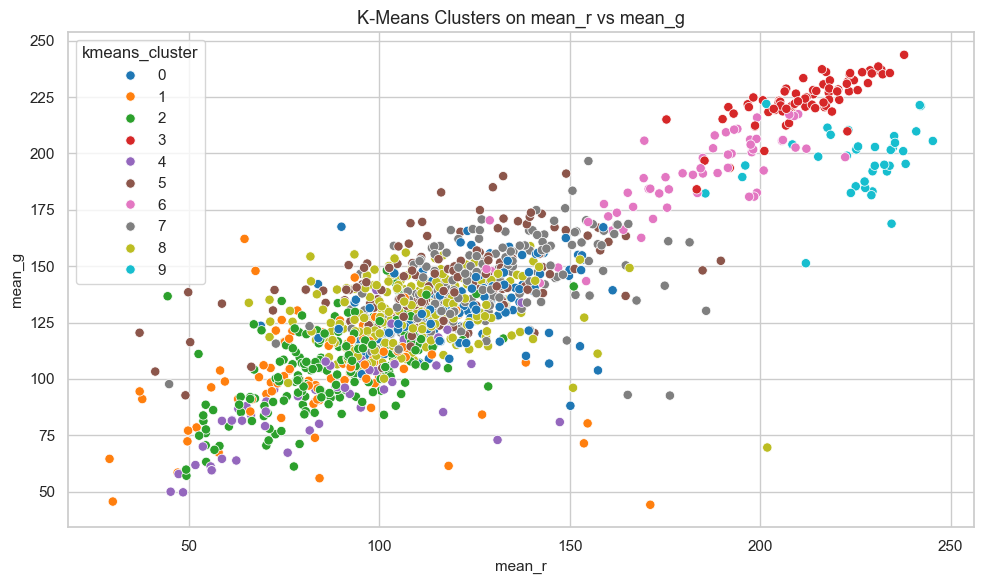

class_name,Blueberry leaf,Corn leaf blight,Corn rust leaf,Peach leaf,Potato leaf early blight,Raspberry leaf,Squash Powdery mildew leaf,Tomato Septoria leaf spot,Tomato leaf bacterial spot,Tomato leaf late blight
kmeans_cluster,,,,,,,,,,
0,9,37,19,10,13,9,22,11,10,15
1,8,18,9,4,13,13,4,9,5,11
2,12,33,9,8,29,25,16,23,19,24
3,19,0,0,25,2,24,0,2,4,0
4,3,6,4,1,11,2,0,15,7,7
5,11,24,26,2,13,8,17,21,16,20
6,9,5,1,14,4,9,1,8,4,3
7,14,30,21,11,12,9,34,28,22,14
8,26,38,27,10,19,17,36,32,23,16


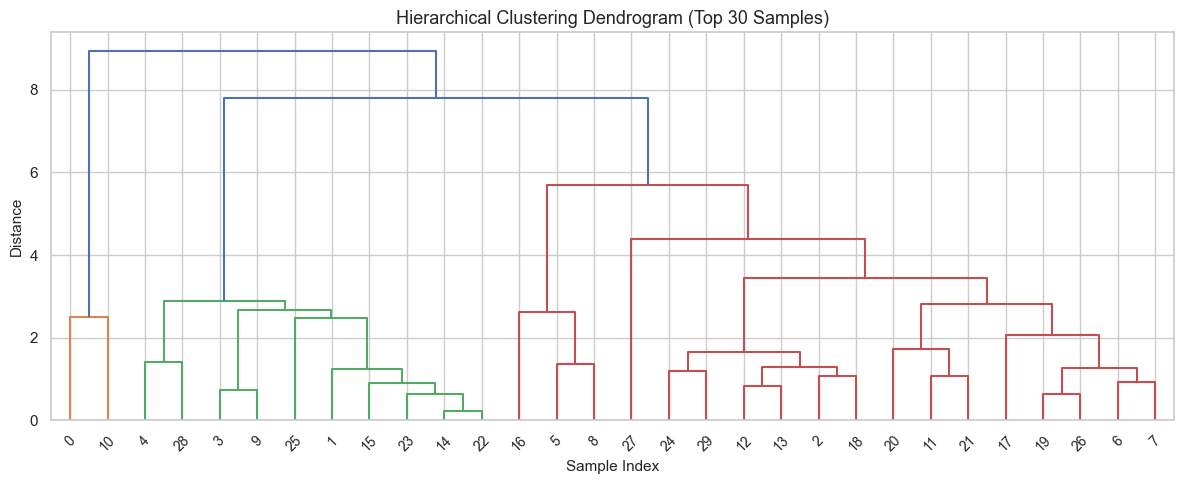

,method,silhouette_score
0,KMeans,0.193766
1,Hierarchical,0.148398


In [2]:
features_df = ensure_features().copy()
feature_cols = ['mean_r', 'mean_g', 'mean_b', 'std_r', 'std_g', 'std_b']

top_10_classes = features_df['class_name'].value_counts().head(10).index
cluster_df = features_df[features_df['class_name'].isin(top_10_classes)].copy().reset_index(drop=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[feature_cols])

inertias = []
ks = list(range(2, 16))
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(ks, inertias, marker='o')
plt.title('Elbow Method for K-Means')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
cluster_df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)
kmeans_silhouette = silhouette_score(X_scaled, cluster_df['kmeans_cluster'])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=cluster_df, x='mean_r', y='mean_g', hue='kmeans_cluster', palette='tab10', s=45)
plt.title('K-Means Clusters on mean_r vs mean_g')
plt.tight_layout()
plt.show()

cluster_vs_class = pd.crosstab(cluster_df['kmeans_cluster'], cluster_df['class_name'])
display(cluster_vs_class)

linkage_input = X_scaled[:30]
linkage_matrix = linkage(linkage_input, method='ward')
plt.figure(figsize=(12, 5))
dendrogram(linkage_matrix)
plt.title('Hierarchical Clustering Dendrogram (Top 30 Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

agglo = AgglomerativeClustering(n_clusters=10)
cluster_df['hier_cluster'] = agglo.fit_predict(X_scaled)
hier_silhouette = silhouette_score(X_scaled, cluster_df['hier_cluster'])

silhouette_comparison = pd.DataFrame({
    'method': ['KMeans', 'Hierarchical'],
    'silhouette_score': [kmeans_silhouette, hier_silhouette]
})
display(silhouette_comparison)

## Results & Evaluation

In [3]:
print('K-Means silhouette score:', round(kmeans_silhouette, 4))
print('Hierarchical silhouette score:', round(hier_silhouette, 4))
print('Cluster vs true label crosstab:')
display(cluster_vs_class)

K-Means silhouette score: 0.1938
Hierarchical silhouette score: 0.1484
Cluster vs true label crosstab:


class_name,Blueberry leaf,Corn leaf blight,Corn rust leaf,Peach leaf,Potato leaf early blight,Raspberry leaf,Squash Powdery mildew leaf,Tomato Septoria leaf spot,Tomato leaf bacterial spot,Tomato leaf late blight
kmeans_cluster,,,,,,,,,,
0,9,37,19,10,13,9,22,11,10,15
1,8,18,9,4,13,13,4,9,5,11
2,12,33,9,8,29,25,16,23,19,24
3,19,0,0,25,2,24,0,2,4,0
4,3,6,4,1,11,2,0,15,7,7
5,11,24,26,2,13,8,17,21,16,20
6,9,5,1,14,4,9,1,8,4,3
7,14,30,21,11,12,9,34,28,22,14
8,26,38,27,10,19,17,36,32,23,16


## Conclusion

Clustering shows how well simple RGB statistics naturally group PlantDoc images without supervision. Comparing K-Means and hierarchical clustering provides insight into whether low-dimensional color features reflect disease-class structure.